# F1 Telemetry EDA — 2024 Bahrain GP (Race)

Exploring the telemetry pulled by `f1telemetry.data.ingest` and trying out the
baseline anomaly model from `f1telemetry.models.baseline` on real data.

Run `python -m f1telemetry.data.ingest 2024 Bahrain --session R` first if
`data/raw/telemetry.parquet` doesn't exist yet.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from f1telemetry.data.ingest import load_session
from f1telemetry.features.build_features import build_telemetry_features
from f1telemetry.models.baseline import BaselineAnomalyModel

%matplotlib inline

## 1. Load and sanity-check the telemetry

Before trusting anything downstream, check that the pulled data looks like real F1 telemetry: plausible top speeds, expected drivers, no obviously broken columns.

In [3]:
telemetry = pd.read_parquet("../data/raw/telemetry.parquet")
print(telemetry.shape)
telemetry.head()

(8161, 13)


,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance,Driver,LapNumber
0,2026-09-13 14:28:51.241,10752.0,248.0,6,100.0,False,0,car,0 days 00:00:00.298000,0 days 02:23:00.801000,20.528889,NOR,52.0
1,2026-09-13 14:28:51.641,11002.0,260.0,7,100.0,False,0,car,0 days 00:00:00.698000,0 days 02:23:01.201000,49.417778,NOR,52.0
2,2026-09-13 14:28:52.001,11446.0,270.0,7,100.0,False,0,car,0 days 00:00:01.058000,0 days 02:23:01.561000,76.417778,NOR,52.0
3,2026-09-13 14:28:52.201,11481.0,275.0,7,100.0,False,0,car,0 days 00:00:01.258000,0 days 02:23:01.761000,91.695556,NOR,52.0
4,2026-09-13 14:28:52.481,11654.0,282.0,7,100.0,False,0,car,0 days 00:00:01.538000,0 days 02:23:02.041000,113.628889,NOR,52.0


In [4]:
top_speed_by_driver = (
    telemetry.groupby("Driver")["Speed"].max().sort_values(ascending=False)
)
top_speed_by_driver

Driver
NOR    344.0
PER    335.0
HUL    330.0
RUS    330.0
ANT    329.0
LIN    329.0
VER    327.0
TSU    327.0
HAM    327.0
COL    326.0
BOR    326.0
OCO    325.0
GAS    324.0
LEC    324.0
BOT    323.0
BEA    323.0
LAW    321.0
PIA    319.0
SAI    318.0
ALB    316.0
ALO    311.0
STR    310.0
Name: Speed, dtype: float64

Top speeds in the ~310-340 km/h range are expected for Bahrain; anything far outside that would suggest a data or units problem worth investigating before going further.

## 2. Baseline anomaly detection on real data

This is the first time we run the feature engineering + Isolation Forest baseline on *real* telemetry rather than synthetic test data.

In [5]:
features = build_telemetry_features(telemetry)
model = BaselineAnomalyModel().fit(features)
scored = model.score(features)

top_anomalies = scored.sort_values("anomaly_score", ascending=False).head(20)
top_anomalies

,Distance,LapNumber,Driver,anomaly_score,is_anomaly
7245,3181.462500,45.0,BOT,0.667862,True
75,1370.196667,52.0,NOR,0.646694,True
3350,375.295278,50.0,HUL,0.638113,True
1859,360.637778,50.0,LEC,0.636185,True
4533,1385.165000,49.0,OCO,0.634620,True
444,1385.147500,36.0,GAS,0.634557,True
6274,5116.090556,50.0,BOR,0.633205,True
3781,1372.531389,52.0,VER,0.629151,True
1074,4856.246944,16.0,PER,0.627982,True
1921,1392.784444,50.0,LEC,0.627615,True


In [ ]:
driver_to_plot = top_anomalies["Driver"].mode()[0]
lap_telemetry = telemetry[telemetry["Driver"] == driver_to_plot].sort_values("Distance")
lap_scored = scored[scored["Driver"] == driver_to_plot].sort_values("Distance")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lap_telemetry["Distance"], lap_telemetry["Speed"], label="Speed")
anomaly_points = lap_scored[lap_scored["is_anomaly"]]
anomaly_speeds = lap_telemetry.set_index("Distance").reindex(
    anomaly_points["Distance"], method="nearest"
)["Speed"]
ax.scatter(
    anomaly_points["Distance"], anomaly_speeds, color="red", zorder=5, label="Flagged anomaly"
)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title(f"{driver_to_plot} — Speed trace with flagged anomalies")
ax.legend()
plt.show()

Look at *where* the red points land: near heavy braking zones or DRS activation is expected
and not very interesting on its own. A flag with no obvious cause (mid-straight, no braking,
no gear change) is either a genuinely odd telemetry moment or a sign the features need work.

## 3. Cross-check against real race events

FastF1 also exposes `race_control_messages` (flags, safety cars, incidents) for the session.

**Important limitation:** `f1telemetry.data.ingest` currently only pulls each driver's
*fastest lap*, not the full race. Race control incidents happen on whatever lap they happen
on, so they won't line up with a fastest-lap anomaly unless the incident happened to occur
during that specific lap. A real "does the model catch real incidents" validation needs
full-session telemetry (all laps), which is a good candidate for tomorrow's LSTM work rather
than this baseline. For now, this section is just to see what kind of events exist in this
session and get familiar with the data — not to claim a validated correlation yet.

In [8]:
session = load_session(2026, "Madrid", "R")  # cached, should be fast
race_control = session.race_control_messages
race_control[["Time", "Category", "Message", "Flag", "Scope", "RacingNumber"]].head(30)

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 12 completed the race distance 00:00.009000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '1', '16', '63', '30', '43', '81', '41', '27', '31', '1

,Time,Category,Message,Flag,Scope,RacingNumber
0,2026-09-13 12:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,GREEN,Track,None
1,2026-09-13 12:25:09,Other,YELLOW IN PIT LANE,None,None,None
2,2026-09-13 12:28:02,Other,PIT LANE CLEAR,None,None,None
3,2026-09-13 12:30:01,Other,PIT EXIT CLOSED,None,None,None
4,2026-09-13 12:45:08,Other,RISK OF RAIN FOR THE F1 RACE IS 0%,None,None,None
5,2026-09-13 12:50:20,Flag,YELLOW IN TRACK SECTOR 10,YELLOW,Sector,None
6,2026-09-13 12:50:41,Flag,CLEAR IN TRACK SECTOR 10,CLEAR,Sector,None
7,2026-09-13 12:57:03,Other,OVERTAKE DISABLED,None,None,None
8,2026-09-13 13:04:04,Other,RACE START,None,None,None
9,2026-09-13 13:04:15,Flag,YELLOW IN TRACK SECTOR 2,YELLOW,Sector,None


In [9]:
# Messages that look like actual flags/incidents, as a starting point for tomorrow's
# full-session anomaly work.
incident_like = race_control[race_control["Category"].isin(["Flag", "SafetyCar", "Drs"])]
incident_like

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2026-09-13 12:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
5,2026-09-13 12:50:20,Flag,YELLOW IN TRACK SECTOR 10,None,YELLOW,Sector,10.0,None,1
6,2026-09-13 12:50:41,Flag,CLEAR IN TRACK SECTOR 10,None,CLEAR,Sector,10.0,None,1
9,2026-09-13 13:04:15,Flag,YELLOW IN TRACK SECTOR 2,None,YELLOW,Sector,2.0,None,1
10,2026-09-13 13:04:15,Flag,YELLOW IN TRACK SECTOR 1,None,YELLOW,Sector,1.0,None,1
...,...,...,...,...,...,...,...,...,...
178,2026-09-13 14:47:33,Flag,YELLOW IN TRACK SECTOR 3,None,YELLOW,Sector,3.0,None,57
179,2026-09-13 14:47:34,Flag,DOUBLE YELLOW IN TRACK SECTOR 6,None,DOUBLE YELLOW,Sector,6.0,None,57
180,2026-09-13 14:47:34,Flag,YELLOW IN TRACK SECTOR 5,None,YELLOW,Sector,5.0,None,57
181,2026-09-13 14:47:47,Flag,CLEAR IN TRACK SECTOR 3,None,CLEAR,Sector,3.0,None,57


## 4. Compare two drivers' telemetry

A quick visual gut-check: overlay Speed vs Distance for the two fastest drivers on their fastest laps. Differences in braking points and corner-exit speed should be visible.

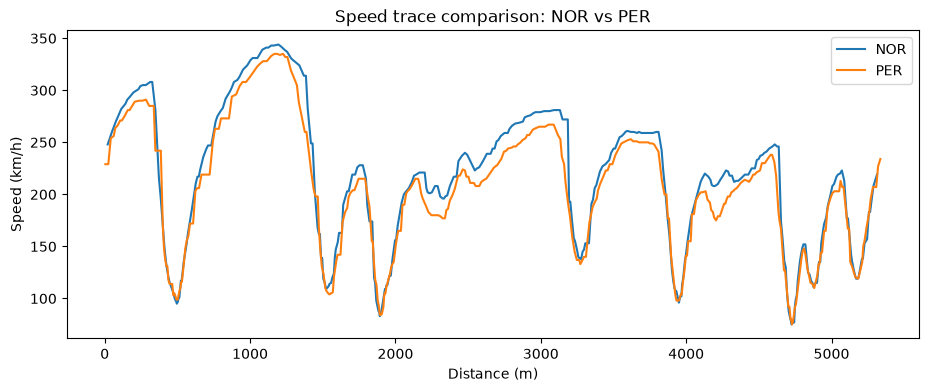

In [10]:
top_two = top_speed_by_driver.head(2).index.tolist()

fig, ax = plt.subplots(figsize=(11, 4))
for driver in top_two:
    lap = telemetry[telemetry["Driver"] == driver].sort_values("Distance")
    ax.plot(lap["Distance"], lap["Speed"], label=driver)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title(f"Speed trace comparison: {top_two[0]} vs {top_two[1]}")
ax.legend()
plt.show()